# Model predictive control (MPC)

This notebook shows how to implement model predictive control in Dynestyx. We consider the controlled discrete time dynamics from the [controller demo](controller_demo.ipynb):
$$
\begin{aligned}
&x_0 \sim p(x_0)\\
&y_0 | x_0 \sim p(y_0 | x_0, t_0) \\
&\hat{x}_{0|0} = \text{FilterUpdate}(y_0, t_0) \\
&u_k, s_{k+1} = \text{ControlPolicy}(\hat{x}_{k|k}, t_{k}, t_{k+1}, s_k) \\
&x_{k+1} | x_k, u_k \sim p(x_{k+1} | x_k, u_k, t_k, t_{k+1}) \\
&y_{k+1} | x_{k+1}, u_k \sim p(y_{k+1} | x_{k+1}, u_k, t_{k+1}) \\
&\hat{x}_{k+1|k+1} = \text{FilterUpdate}(\hat{x}_{k|k}, u_k, y_{k+1}, t_k, t_{k+1}) \\
\end{aligned}
$$

In MPC, the policy $\pi$ chooses the control optimizes a set of controls $u_{k:k+N}$ over finite horizon $N$ to minimize some loss function, using a dynamical model (either the true state transition $p$ or some approximation $\hat{p}$). It then executes the first control $u_k$ before repeating this procedure [1].


In [1]:
import dynestyx as dsx
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro.distributions as dist

from dynestyx.models import DynamicalModel
from dynestyx.models.observations import LinearGaussianObservation
from dynestyx.models.state_evolution import LinearGaussianStateEvolution

## 1. Dynamics

We consider the same dynammics as in [controller demo](controller_demo.ipynb) where  $x_t \in \mathbb{R}^2$ obeys
$$
\begin{aligned}
dx_t &= A x_t^2 + u_t + \sigma\, dW_t \\
x_{t_k} &= x_{t_{k-1}} + \int_{t_{k-1}}^{t_k} Ax_s^2 + u_s ds + \sigma\int_{t_{k-1}}^{t_k}dW_s
\\
y_{t_k} &= H x_{t_k} + \eta_{t_k}
\end{aligned}
$$
with $A = \begin{pmatrix} 0.025 & 0.01 \\ 0.01 & 0.025 \end{pmatrix}$, $H = \begin{pmatrix} 1 & 0
\end{pmatrix}$ (i.e. we only observe the first component), and $x^2 = x \odot x$ (the square applied component wise). The discrete time dynamics are given by the continuous dynamics at discrete time $t_k = \Delta t k$. 

In [2]:
from dynestyx.inference.configs.filter import EnKFConfig, PFConfig
from dynestyx.models import FullDiffusion

state_dim_2d = control_dim_2d = 2
obs_dim_2d = 1
A = jnp.array([[0.025, 0.01], [0.01, 0.025]])
sigma_2d = 0.1

In [3]:
from dynestyx.models import StochasticContinuousTimeStateEvolution
from dynestyx.solvers import euler_maruyama_integrate_state_to_time

substep_dt = 0.02  # ~5 EM sub-steps per 0.1-spaced observation interval

cte = StochasticContinuousTimeStateEvolution(
    drift=lambda x, u, t: A @ (x**2) + u,
    diffusion=FullDiffusion(sigma_2d * jnp.eye(state_dim_2d)),  # bm_dim inferred from the matrix shape
)


class SubSteppedSDEStep:
    """A single control-loop transition that is itself a sub-stepped SDE
    integration -- the simulator only ever sees `.sample()`/`.shape()`,
    exactly as it would for e.g. a MuJoCo step."""

    def __init__(self, cte, x_prev, u, t_now, t_next, *, dt0):
        self._cte, self._x_prev, self._u = cte, x_prev, u
        self._t_now, self._t_next, self._dt0 = t_now, t_next, dt0

    def sample(self, key):
        x_out, _, _ = euler_maruyama_integrate_state_to_time(
            self._cte,
            self._x_prev,
            self._t_now,
            key,
            self._t_next,
            dt0=self._dt0,
            control_path_eval=lambda t: self._u,
        )
        return x_out

    def shape(self):
        return self._x_prev.shape


def black_box_sde_transition(x, u, t_now, t_next):
    return SubSteppedSDEStep(cte, x, u, t_now, t_next, dt0=substep_dt)


In [4]:
nonlinear_dynamics = DynamicalModel(
    initial_condition=dist.MultivariateNormal(
        jnp.array([3.0, 2.0]), 0.05 * jnp.eye(state_dim_2d)), #can be replaced with any numpyro distribution
    state_evolution=black_box_sde_transition,
    observation_model=LinearGaussianObservation(
        H=jnp.eye(obs_dim_2d, state_dim_2d), R=0.05 * jnp.eye(obs_dim_2d)
    ),
    control_dim=control_dim_2d,
)

## 2. A sampling-based MPC: Model Predictive Path Integral (MPPI)

`dynestyx.control.MPPI` implements a type of model predictive control.

Model Predictive Path Integral control [2] is a sampling based approach to solving the optimization problem. At every step, we sample many candidate control sequences, roll each one forward through the state transition, score them with a cost function, and take the softmax-weighted average as the actual control (only the first step of that average is applied; the rest becomes next step's warm-started plan).

MPPI needs the **one-step dynamics**, a black-box transition kernel (the same one used for the real simulation, or a distinct approximate one for planning), and a **loss function** scoring a rolled-out trajectory.

The loss function must take `ControlledSimulatedResult` (for one control path) and return a scalar.
**Optional arguments**

`horizon`: how many time-steps to plan ahead.

`n_samples`: the number of sampled controll paths.  

In [11]:
from dynestyx.control import MPPI


def quadratic_loss(result):  # drives the state to zero while penalizing control effort
    loss = jnp.sum(result.states[0, 1:]**2) # we remove the first state (initial condition)
    loss+= 0.01 * jnp.sum(result.controls[0]**2)
    return loss

In [12]:
predict_times_2d = jnp.arange(0.0, 6.0, 0.1)
horizon = 10
n_samples = 50

mppi = MPPI(
    dynamics=nonlinear_dynamics,
    loss_fn=quadratic_loss,
    horizon=horizon,
    n_samples=n_samples,
)

key_2d = jr.PRNGKey(0)
result_mppi = dsx.simulate(
    nonlinear_dynamics,
    rng_key=key_2d,
    predict_times=predict_times_2d,
    control_policy=mppi,
    filter_config=PFConfig(n_particles=500, record_filtered_states_mean=True),
    initial_policy_state=mppi.initial_state(),
)


def zero_policy(x_hat, t_now, t_next, s):
    return jnp.zeros(control_dim_2d), s


result_uncontrolled = dsx.simulate(
    nonlinear_dynamics,
    rng_key=key_2d,
    predict_times=predict_times_2d,
    control_policy=zero_policy,
    filter_config=PFConfig(n_particles=500, record_filtered_states_mean=True),
)

Same reading as before: observed (dots) and filtered (solid) state, contrasted no-control baseline (same dynamics, same key), plus MPPI's chosen control sequence.

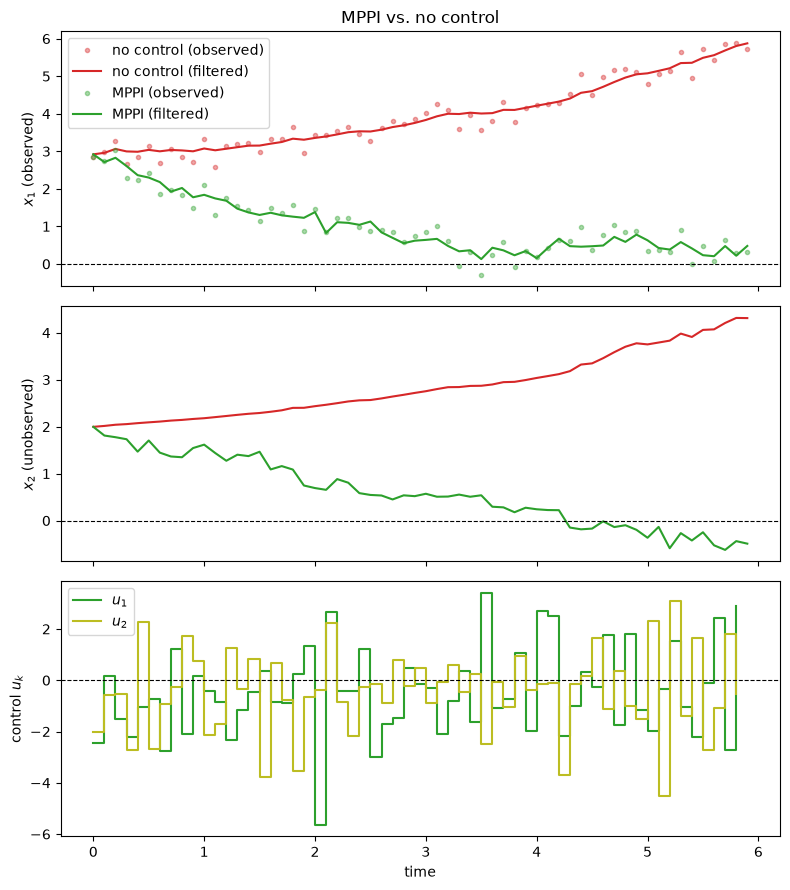

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

runs_mppi = [
    (result_uncontrolled, "no control", "tab:red"),
    (result_mppi, "MPPI", "tab:green"),
]
for result, label, color in runs_mppi:
    t = result.times[0]
    filtered_mean = result.filtered_states_mean[0]
    axes[0].plot(t, result.observations[0, :, 0], ".", color=color, alpha=0.4, label=f"{label} (observed)")
    axes[0].plot(t, filtered_mean[:, 0], "-", color=color, label=f"{label} (filtered)")
    axes[1].plot(t, filtered_mean[:, 1], "-", color=color)

axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("$x_1$ (observed)")
axes[0].legend()
axes[0].set_title("MPPI vs. no control")

axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("$x_2$ (unobserved)")

t_u = result_mppi.times[0][:-1]
u = result_mppi.controls[0]
axes[2].step(t_u, u[:, 0], where="post", color="tab:green", label="$u_1$")
axes[2].step(t_u, u[:, 1], where="post", color="tab:olive", label="$u_2$")
axes[2].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_ylabel("control $u_k$")
axes[2].set_xlabel("time")
axes[2].legend()

plt.tight_layout()
plt.show()

## References

1. Rawlings, J. B., Mayne, D. Q., & Diehl, M. M. (2017). *Model Predictive Control: Theory, Computation, and Design* (2nd ed.). Nob Hill Publishing.
2. Williams, G., Aldrich, A., & Theodorou, E. A. (2017). Model Predictive Path Integral Control: From Theory to Parallel Computation. *Journal of Guidance, Control, and Dynamics*, 40(2), 344–357.